Success! Plot saved to:
C:\Users\kaush\Desktop\Codes\Rainfall_plotter\CCS_2025032500_2025040223_plot.png


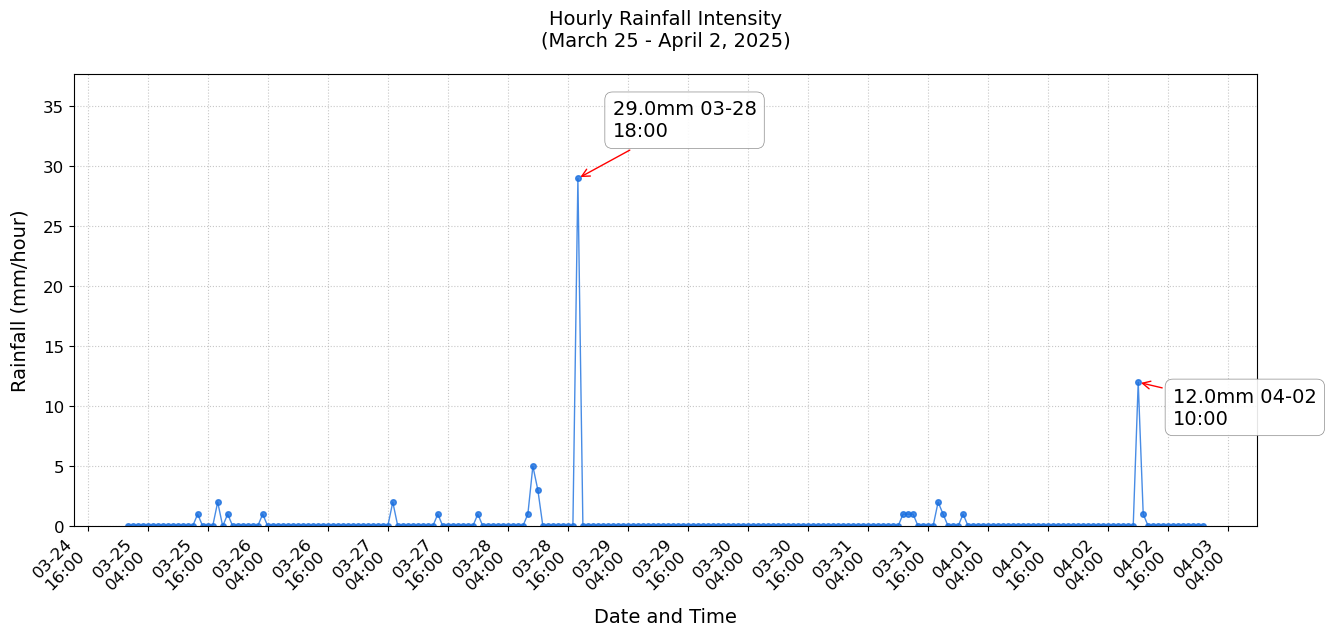

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, HourLocator
import datetime
import os
from textwrap import fill

# ===== USER CONFIGURATION =====
# Customize these settings as needed:
CSV_FILENAME = 'CCS_2025032500_2025040223.csv'  # Name of your CSV file
FONT_SETTINGS = {
    'family': 'DejaVu Sans',  # Default font that works across systems
    'size_title': 14,         # Title font size
    'size_labels': 14,        # Axis label font size
    'size_ticks': 12,         # Tick label font size
    'size_annotations': 14,    # Annotation font size
}
DPI = 300                    # Output image resolution
# ===== END CONFIGURATION =====

def validate_font(font_name):
    """Check if a font is available on the system"""
    from matplotlib.font_manager import FontManager
    return font_name in FontManager().get_font_names()

try:
    # Validate font
    if not validate_font(FONT_SETTINGS['family']):
        available_fonts = plt.rcParams['font.family']
        print(f"Font '{FONT_SETTINGS['family']}' not available. Using default font.")
        FONT_SETTINGS['family'] = plt.rcParams['font.family'][0]

    # Read and process data
    if not os.path.exists(CSV_FILENAME):
        raise FileNotFoundError(f"Could not find file: {CSV_FILENAME}")
    
    df = pd.read_csv(CSV_FILENAME, skiprows=1, header=None, names=['Time', 'Rain(mm)'])
    df['Datetime'] = df['Time'].str.extract(r'_1h(\d+)')[0].apply(
        lambda x: datetime.datetime.strptime(x, "%Y%m%d%H"))

    # Create plot with clean style
    plt.style.use('default')  # Using default matplotlib style
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Apply font settings
    plt.rcParams['font.family'] = FONT_SETTINGS['family']
    title_font = {'fontname': FONT_SETTINGS['family'], 'size': FONT_SETTINGS['size_title']}
    label_font = {'fontname': FONT_SETTINGS['family'], 'size': FONT_SETTINGS['size_labels']}
    tick_font = {'fontname': FONT_SETTINGS['family'], 'size': FONT_SETTINGS['size_ticks']}

    # Plot data
    ax.plot(df['Datetime'], df['Rain(mm)'], 
           marker='o', markersize=4, 
           linestyle='-', linewidth=1,
           color='#1a6fdf', alpha=0.8)

    # Format axes with user fonts
    ax.xaxis.set_major_formatter(DateFormatter('%m-%d\n%H:%M'))
    ax.xaxis.set_major_locator(HourLocator(interval=12))
    plt.xticks(rotation=45, ha='right', **tick_font)
    plt.yticks(**tick_font)
    
    # Set dynamic limits with padding
    ymax = max(10, df['Rain(mm)'].max() * 1.3)
    ax.set_ylim(0, ymax)

    # Add labels with user fonts
    ax.set_xlabel('Date and Time', **label_font, labelpad=10)
    ax.set_ylabel('Rainfall (mm/hour)', **label_font, labelpad=10)
    ax.set_title('Hourly Rainfall Intensity\n(March 25 - April 2, 2025)', **title_font, pad=20)
    ax.grid(True, linestyle=':', alpha=0.7)

    # Annotate peaks with smart positioning
    peaks = df.nlargest(2, 'Rain(mm)')
    for i, (_, row) in enumerate(peaks.iterrows()):
        label = fill(f"{row['Rain(mm)']}mm\n{row['Datetime'].strftime('%m-%d %H:%M')}", width=15)
        y_offset = 30 if i == 0 else -30
        y_pos = min(row['Rain(mm)'] + ymax*0.1, ymax*0.9) if i == 0 else max(row['Rain(mm)'] - ymax*0.1, ymax*0.1)
        
        ax.annotate(label,
                  xy=(row['Datetime'], row['Rain(mm)']),
                  xytext=(25, y_offset),
                  textcoords='offset points',
                  fontsize=FONT_SETTINGS['size_annotations'],
                  arrowprops=dict(arrowstyle="->", color='red', lw=1),
                  bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=0.5, alpha=0.9))

    # Final layout adjustments
    plt.tight_layout(pad=3.0)
    output_file = f"{os.path.splitext(CSV_FILENAME)[0]}_plot.png"
    plt.savefig(output_file, dpi=DPI, bbox_inches='tight')
    print(f"Success! Plot saved to:\n{os.path.abspath(output_file)}")
    plt.show()

except FileNotFoundError:
    print(f"Error: File '{CSV_FILENAME}' not found in:\n{os.getcwd()}")
except Exception as e:
    print(f"Error: {str(e)}")
    print("\nTroubleshooting tips:")
    print("- Verify CSV exists and has correct format")
    print("- Try these available fonts:", plt.rcParams['font.family'])
    print("- Reduce font sizes if needed")
    print("- Check datetime format in CSV")